In [1]:
# 02 - Sentiment Analysis (Third Wave American Ska)
# 
# Goal:
# - Measure emotional tone per song and per line
# - Identify emotional volatility
# - Establish a genre level baseline 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from pathlib import Path

DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "processed/lyrics_clean.csv")

df.shape

(65, 8)

In [3]:
def split_lines(text: str):
    return [l for l in str(text).split("\n") if l.strip()]

df["lines"] = df["lyrics_clean"].apply(split_lines)
df["line_count"] = df["lines"].apply(len)

df[["line_count"]].describe()

,line_count
count,65.000000
mean,43.030769
std,15.352086
min,14.000000
25%,33.000000
50%,41.000000
75%,48.000000
max,96.000000


In [4]:
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/ryanhoffman/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [5]:
def song_sentiment(lines):
    scores = [sia.polarity_scores(l)["compound"] for l in lines]
    if not scores:
        return pd.Series({
            "sent_mean": np.nan,
            "sent_std": np.nan,
            "sent_min": np.nan,
            "sent_max": np.nan
        })
    return pd.Series({
        "sent_mean": np.mean(scores),
        "sent_std": np.std(scores),
        "sent_min": np.min(scores),
        "sent_max": np.max(scores)
    })

sentiment = df["lines"].apply(song_sentiment)
df = pd.concat([df, sentiment], axis=1)

df[["sent_mean", "sent_std"]].describe()

,sent_mean,sent_std
count,65.000000,65.000000
mean,0.005124,0.272824
std,0.121716,0.083678
min,-0.501264,0.078734
25%,-0.046628,0.221935
50%,0.005567,0.271302
75%,0.061708,0.333511
max,0.448287,0.450981


In [6]:
# 1) Remove duplicate-named columns created by repeated concat
df = df.loc[:, ~df.columns.duplicated()].copy()

# 2) (Recommended) Stop using concat going forward: overwrite sentiment columns instead
#    Recompute sentiment once more and assign by column name (no duplicates possible)
sentiment = df["lines"].apply(song_sentiment)
for col in sentiment.columns:
    df[col] = sentiment[col]

# 3) Verify there are no duplicate columns now
print("Duplicate columns:", df.columns[df.columns.duplicated()].tolist())

# 4) Your summary
df[["sent_mean", "sent_std", "sent_min", "sent_max"]].describe()

Duplicate columns: []


,sent_mean,sent_std,sent_min,sent_max
count,65.000000,65.000000,65.000000,65.000000
mean,0.005124,0.272824,-0.601172,0.594426
std,0.121716,0.083678,0.184253,0.194515
min,-0.501264,0.078734,-0.961200,0.000000
25%,-0.046628,0.221935,-0.726900,0.493900
50%,0.005567,0.271302,-0.612400,0.592700
75%,0.061708,0.333511,-0.476700,0.743000
max,0.448287,0.450981,0.000000,0.958400


In [7]:
# Analysis Time
# Sent_mean: 
# - range: -1 to +1 ~ very negative to very positive
#
# - near 0 means emotionall neutral, ironic, mixed
# - positive means upbeat, hopeful, celebratory
# - negative means angry, bitter, despairing

In [8]:
df[["song_title", "artist", "sent_mean"]]

,song_title,artist,sent_mean
0,The Impression That I Get,The Mighty Mighty Bosstones,0.073378
1,Someday I Suppose,The Mighty Mighty Bosstones,0.014969
2,Here in Your Bedroom,Goldfinger,0.046055
3,No Face,The Suicide Machines,-0.133470
4,Sunday Morning,No Doubt,0.074191
...,...,...,...
60,I Got My Tooth Removed,100 Gecs,0.031769
61,She's Kerosene,The Interrupters,0.016928
62,Such Great Heights,Streetlight Manifesto,0.207235
63,Me and Julio Down By The Schoolyard,Streetlight Manifesto,-0.017647


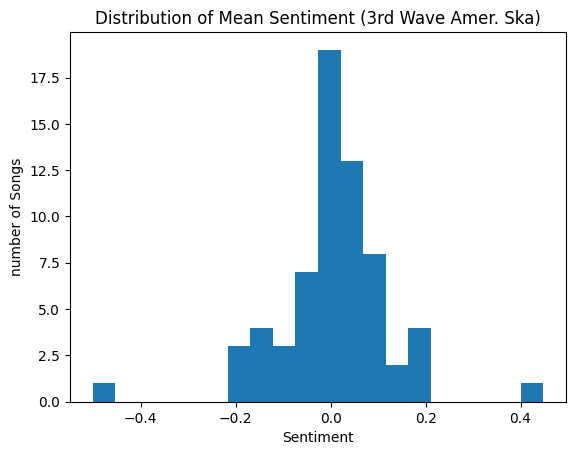

In [9]:
plt.hist(df["sent_mean"], bins=20)
plt.title("Distribution of Mean Sentiment (3rd Wave Amer. Ska)")
plt.xlabel("Sentiment")
plt.ylabel("number of Songs")
plt.show()

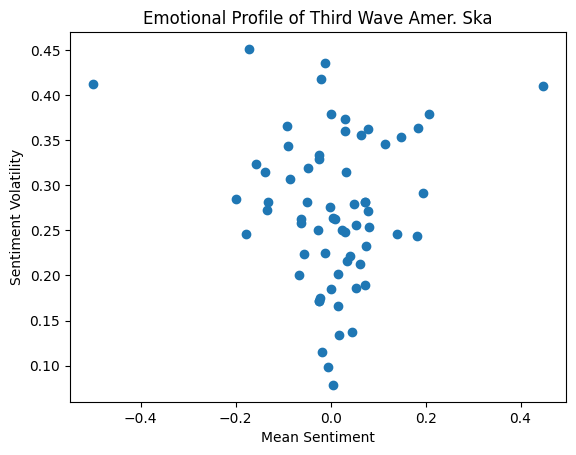

In [10]:
plt.scatter(df["sent_mean"], df["sent_std"])
plt.title("Emotional Profile of Third Wave Amer. Ska")
plt.xlabel("Mean Sentiment")
plt.ylabel("Sentiment Volatility")
plt.show()